# Visualization of prediction of models on test sets

Here is how this notebook differs from `test_predict_viz.ipynb`
- Model used `RandomForestClassifier`
- Feature types:
    - "full"
    - "nocorr"
    - "sel"

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

## Read the data

In [2]:
data_folder = Path("../data/processed/train_test_sets_v2/")

In [3]:
# concatenate all results.json
results_files = data_folder.glob("**/results.json")
results = []
for results_file in results_files:
    with open(results_file) as fid:
        results.append(json.load(fid))
results = pd.DataFrame(results)

In [4]:
results

,feature_name,feature_type,phenotype_name,train_set_id,test_set_id,rep,path,accuracy,balanced_accuracy,matthews_corrcoef
0,kofam,full,Arginine,atleaf+lit,in_abb,0,../data/processed/train_test_sets_v2/feat(kofa...,0.857143,0.822222,0.683537
1,kofam,full,Arginine,atleaf+lit,in_abb,1,../data/processed/train_test_sets_v2/feat(kofa...,0.821429,0.838889,0.651188
2,kofam,full,Arginine,atleaf+lit,in_abb,2,../data/processed/train_test_sets_v2/feat(kofa...,0.928571,0.928571,0.857143
3,kofam,full,Arginine,atleaf+lit,in_abb,3,../data/processed/train_test_sets_v2/feat(kofa...,0.928571,0.927083,0.854167
4,kofam,full,Arginine,atleaf+lit,in_abb,4,../data/processed/train_test_sets_v2/feat(kofa...,0.857143,0.866310,0.717435
...,...,...,...,...,...,...,...,...,...,...
5755,kofam,sel,Glucose,atleaf+lit-a,pmi,0,../data/processed/train_test_sets_v2/feat(kofa...,0.000000,0.000000,0.000000
5756,kofam,sel,Glucose,atleaf+lit-a,pmi,1,../data/processed/train_test_sets_v2/feat(kofa...,0.000000,0.000000,0.000000
5757,kofam,sel,Glucose,atleaf+lit-a,pmi,2,../data/processed/train_test_sets_v2/feat(kofa...,0.000000,0.000000,0.000000
5758,kofam,sel,Glucose,atleaf+lit-a,pmi,3,../data/processed/train_test_sets_v2/feat(kofa...,0.000000,0.000000,0.000000


## Visualize test set performance

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

Let's look at MCC of all the combinations with feature_type along the columns and test_dataset along rows

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


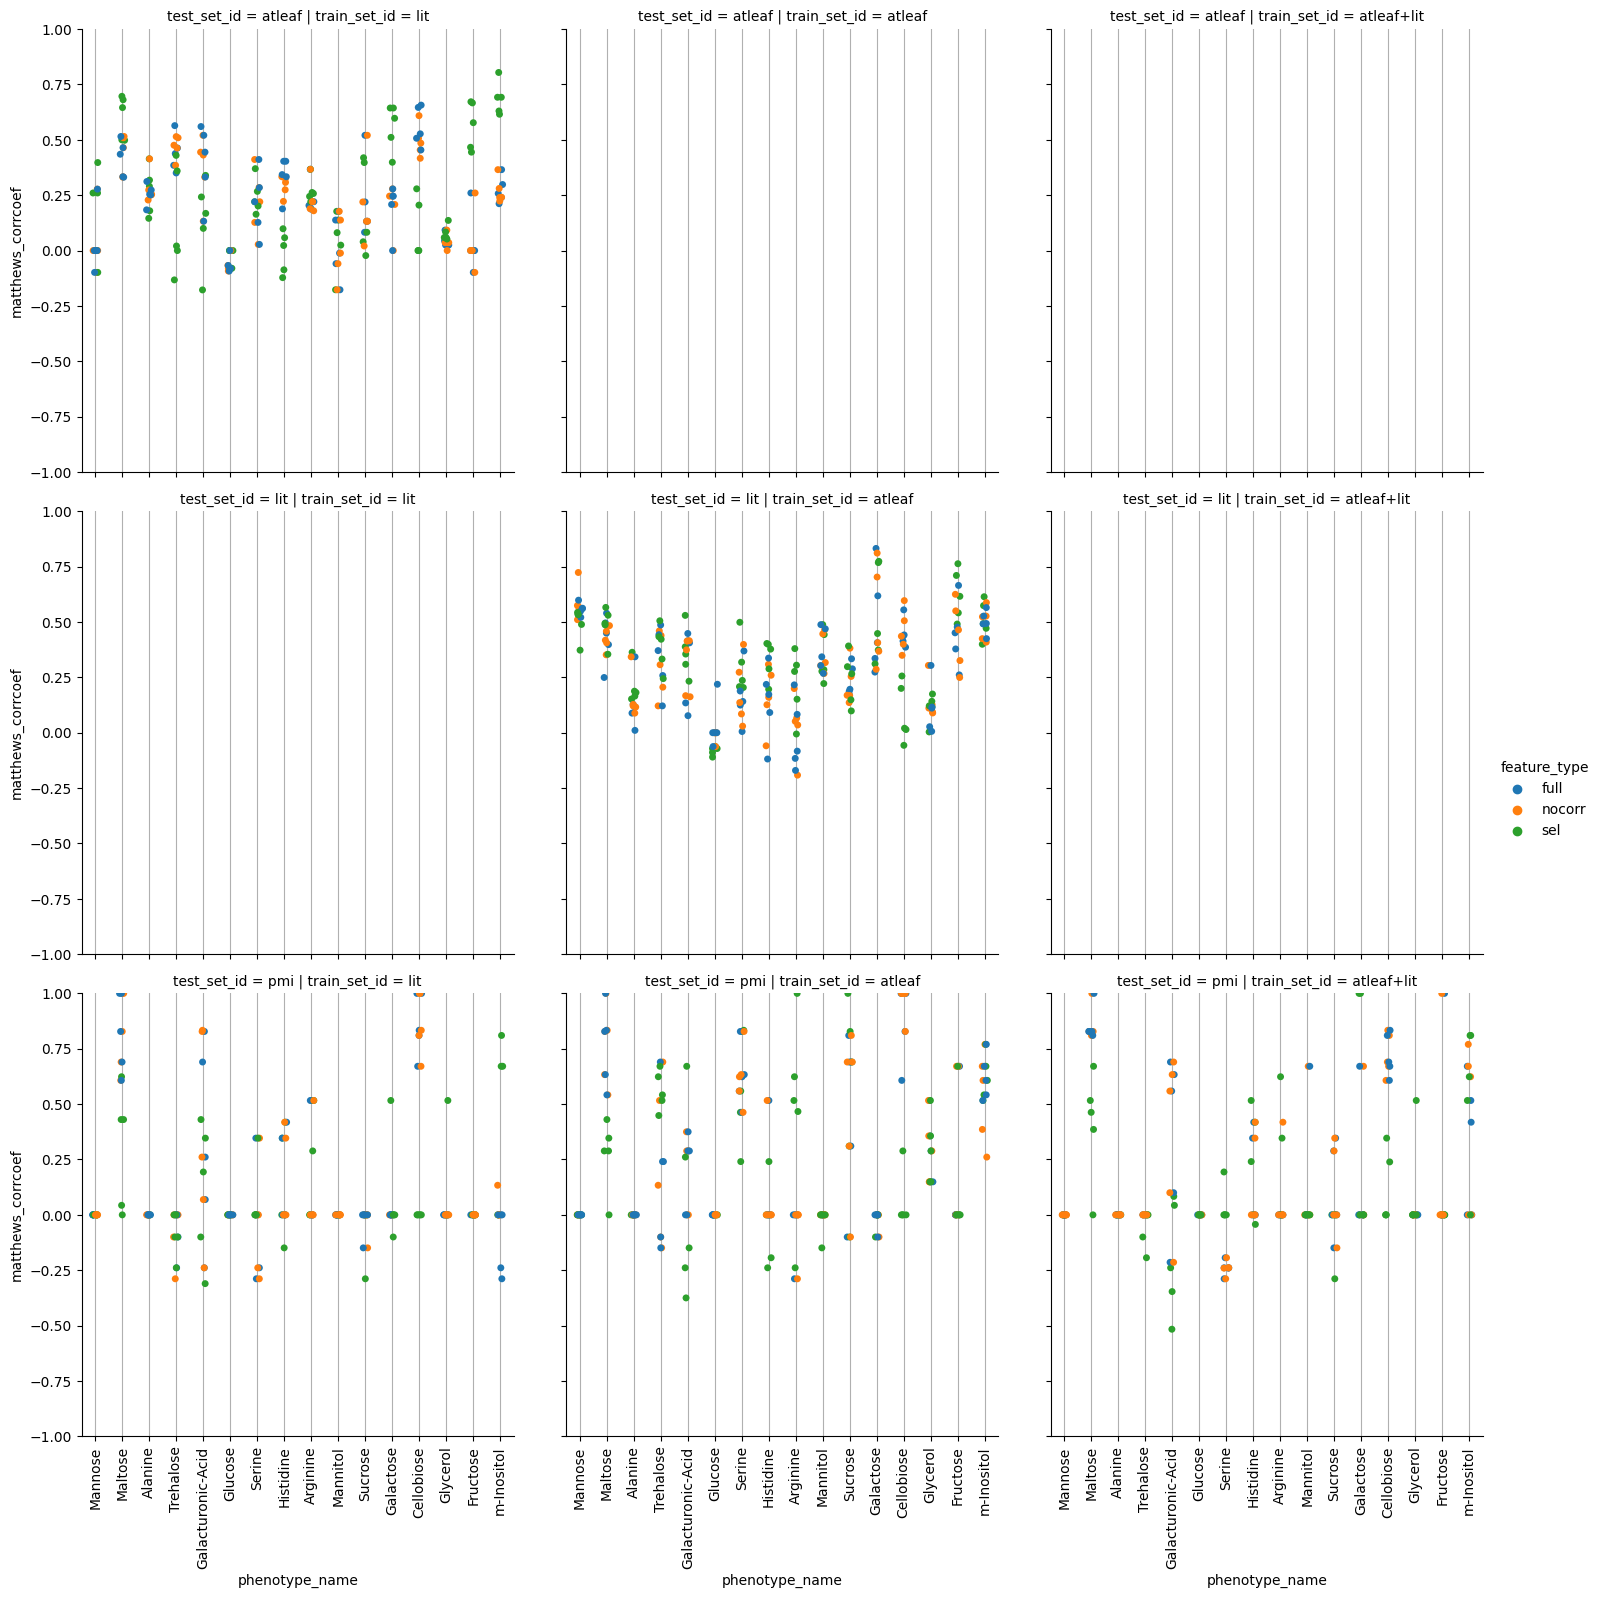

In [6]:
plot_data = results[(results.test_set_id.isin(["lit", "pmi", "atleaf"])) & (results.train_set_id.isin(["atleaf", "lit", "atleaf+lit"]))]
row_order = ["atleaf", "lit", "pmi"]
hue_order = ["full", "nocorr", "sel"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="strip",
    row="test_set_id",
    col="train_set_id",
    row_order=row_order,
    hue_order=hue_order
    )
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

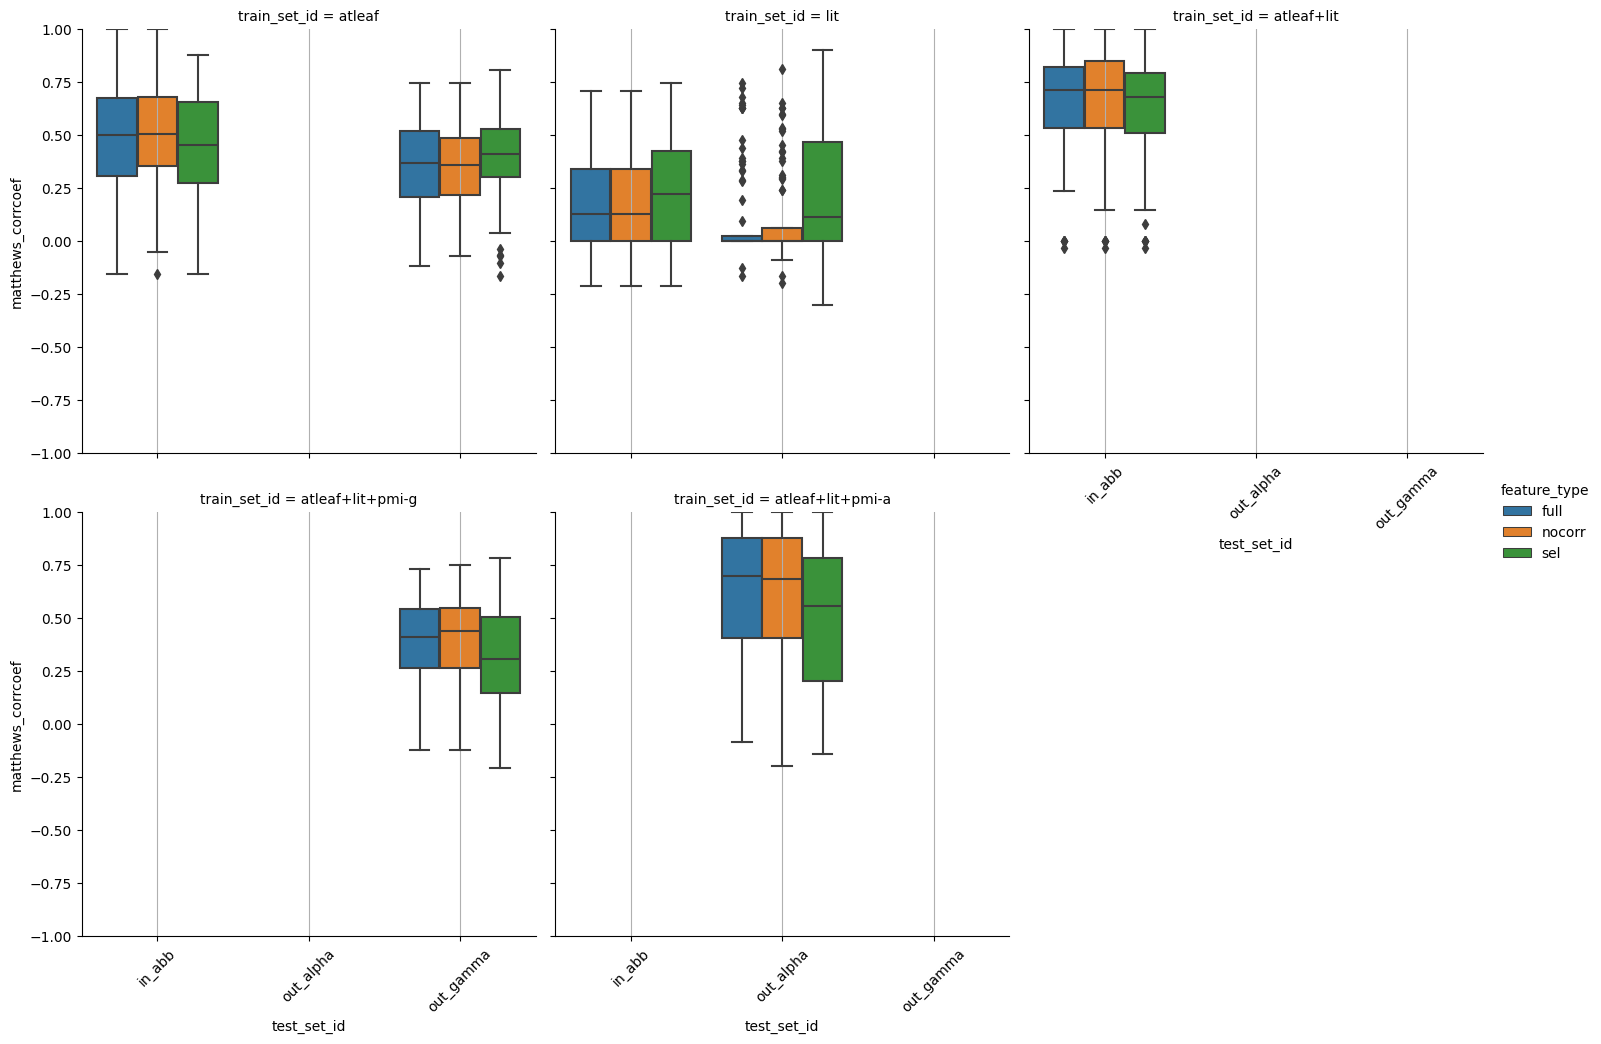

In [7]:
plot_data = results[results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])]
col_order = ["atleaf", "lit", "atleaf+lit", "atleaf+lit+pmi-g", "atleaf+lit+pmi-a"]
hue_order = ["full", "nocorr", "sel"]
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="feature_type",
    col="train_set_id",
    col_wrap=3,
    kind="box",
    hue_order=hue_order,
    col_order=col_order
)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

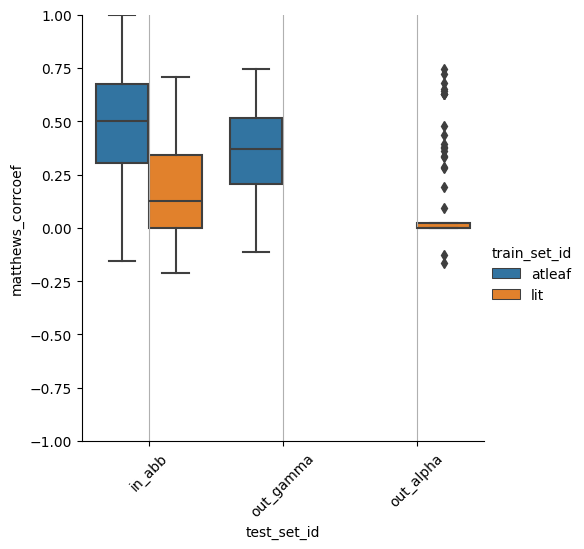

In [8]:
plot_data = results[
    (results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) &
    (results.train_set_id.isin(["atleaf", "lit"])) &
    (results.feature_type.isin(["full"]))
    ]
col_order = ["atleaf", "lit"]
order = ["in_abb", "out_gamma", "out_alpha"]
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="train_set_id",
    kind="box",
    order=order
)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

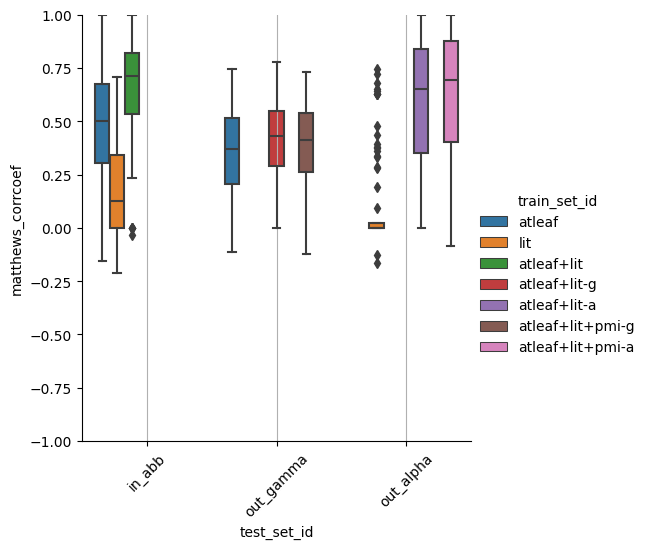

In [9]:
plot_data = results[
    (results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) &
    (results.feature_type.isin(["full"]))
    ]
col_order = ["atleaf", "lit"]
order = ["in_abb", "out_gamma", "out_alpha"]
hue_order = ["atleaf", "lit", "atleaf+lit", "atleaf+lit-g", "atleaf+lit-a", "atleaf+lit+pmi-g", "atleaf+lit+pmi-a"]
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="train_set_id",
    kind="box",
    order=order,
    hue_order=hue_order
)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

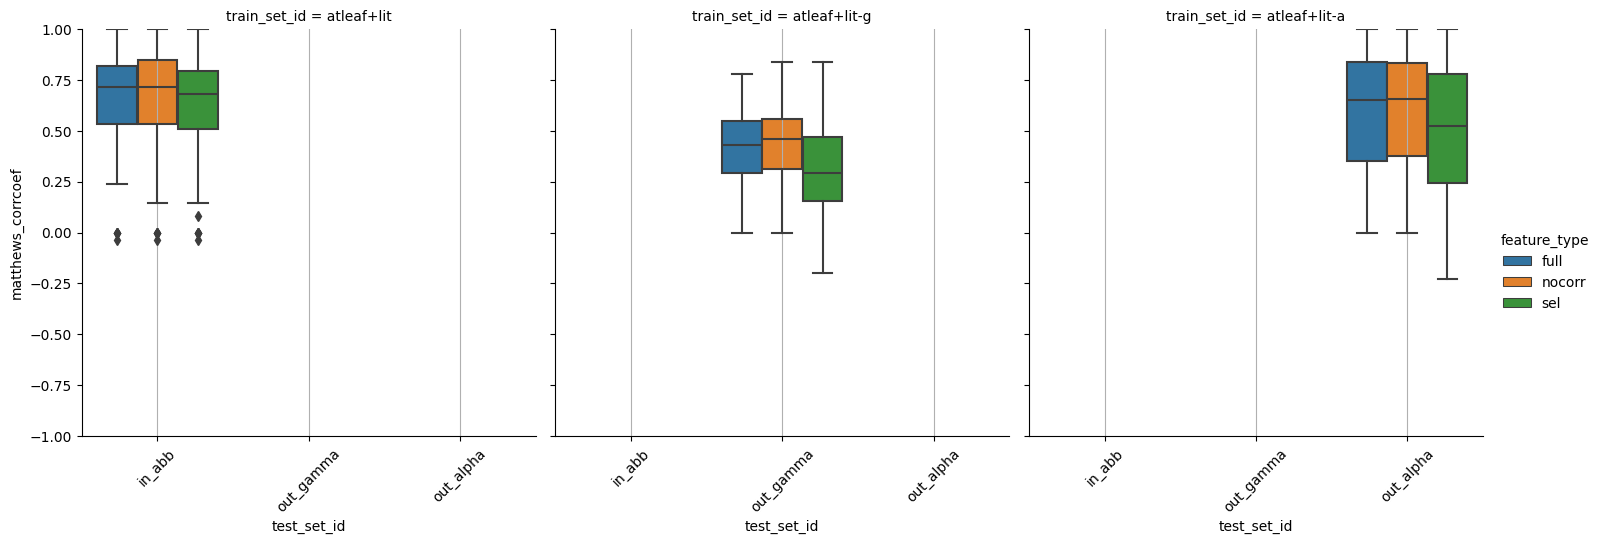

In [10]:
plot_data = results[
    (results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) &
    (results.train_set_id.isin(["atleaf+lit", "atleaf+lit-g", "atleaf+lit-a"])) &
    (results.feature_type.isin(["full", "nocorr", "sel"]))
    ]
order = ["in_abb", "out_gamma", "out_alpha"]
hue_order = ["full", "nocorr", "sel"]
col_order = ["atleaf+lit", "atleaf+lit-g", "atleaf+lit-a"]
g = sns.catplot(
    data=plot_data,
    x="test_set_id",
    y="matthews_corrcoef",
    hue="feature_type",
    col="train_set_id",
    kind="box",
    order=order,
    hue_order=hue_order,
    col_order=col_order
)
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(45)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


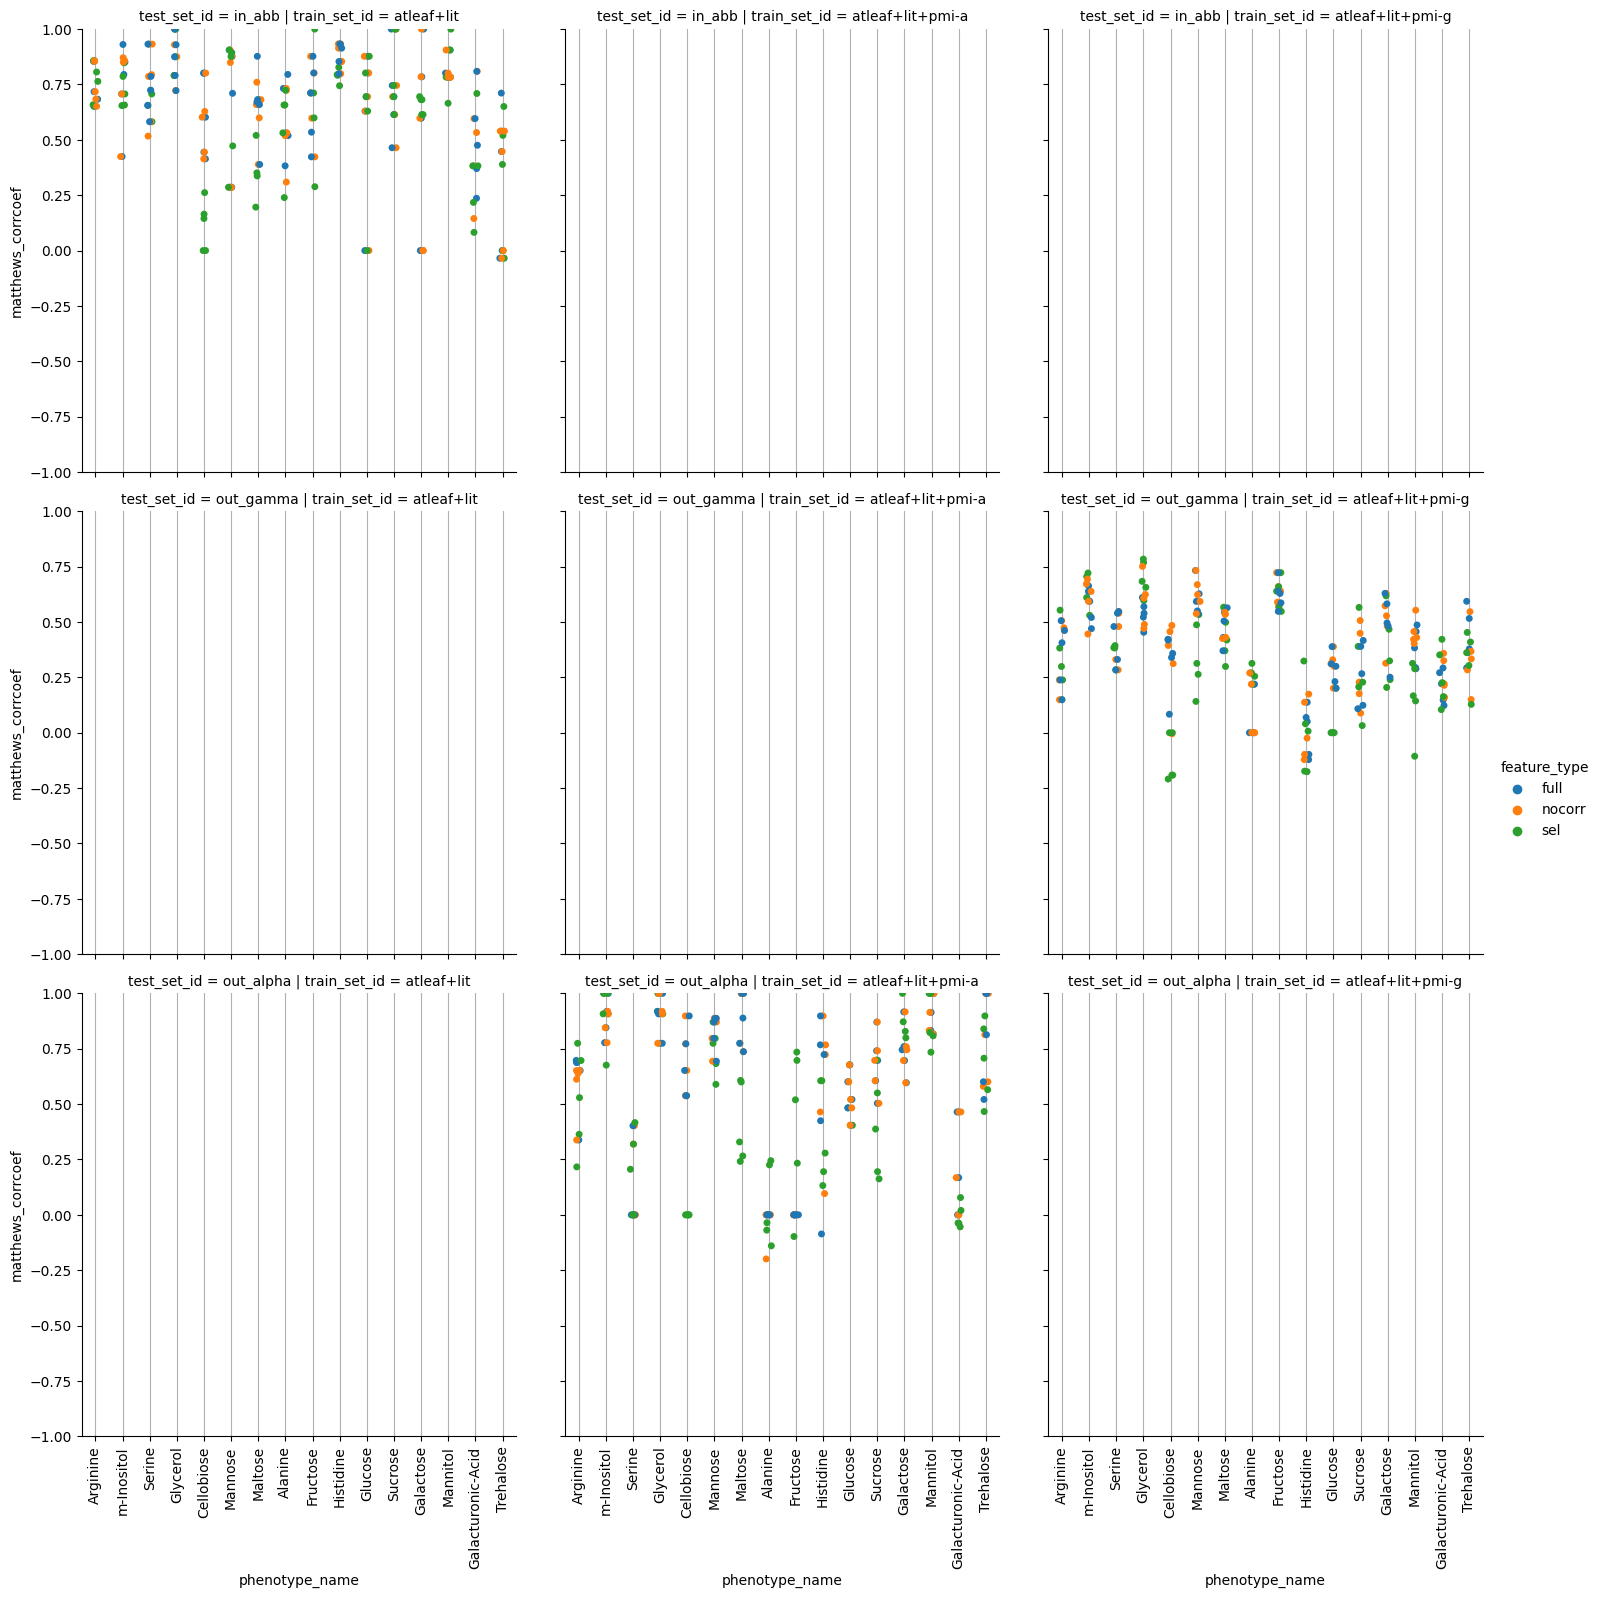

In [12]:
plot_data = results[(results.test_set_id.isin(["in_abb", "out_gamma", "out_alpha"])) & (results.train_set_id.isin(["atleaf+lit", "atleaf+lit+pmi-g", "atleaf+lit+pmi-a"]))]
row_order = ["in_abb", "out_gamma", "out_alpha"]
hue_order = ["full", "nocorr", "sel"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="strip",
    row="test_set_id",
    col="train_set_id",
    row_order=row_order,
    hue_order=hue_order
    )
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


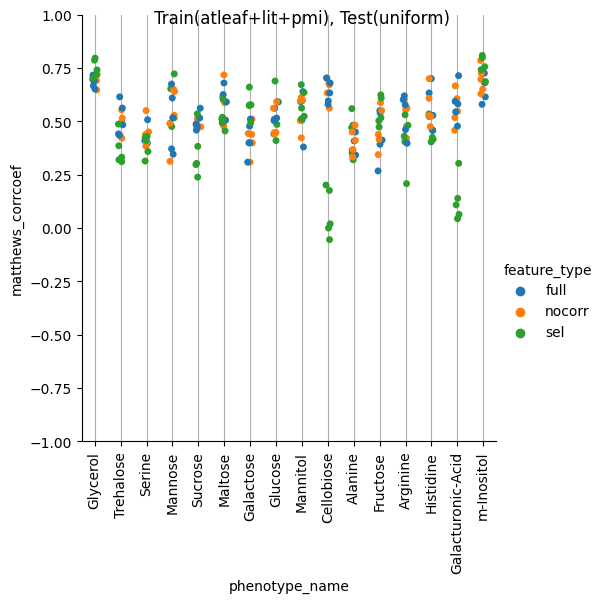

In [13]:
plot_data = results[(results.test_set_id.isin(["uniform"])) & (results.train_set_id.isin(["atleaf+lit+pmi"]))]
hue_order = ["full", "nocorr", "sel"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="strip",
    hue_order=hue_order
    )
g.fig.suptitle("Train(atleaf+lit+pmi), Test(uniform)")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


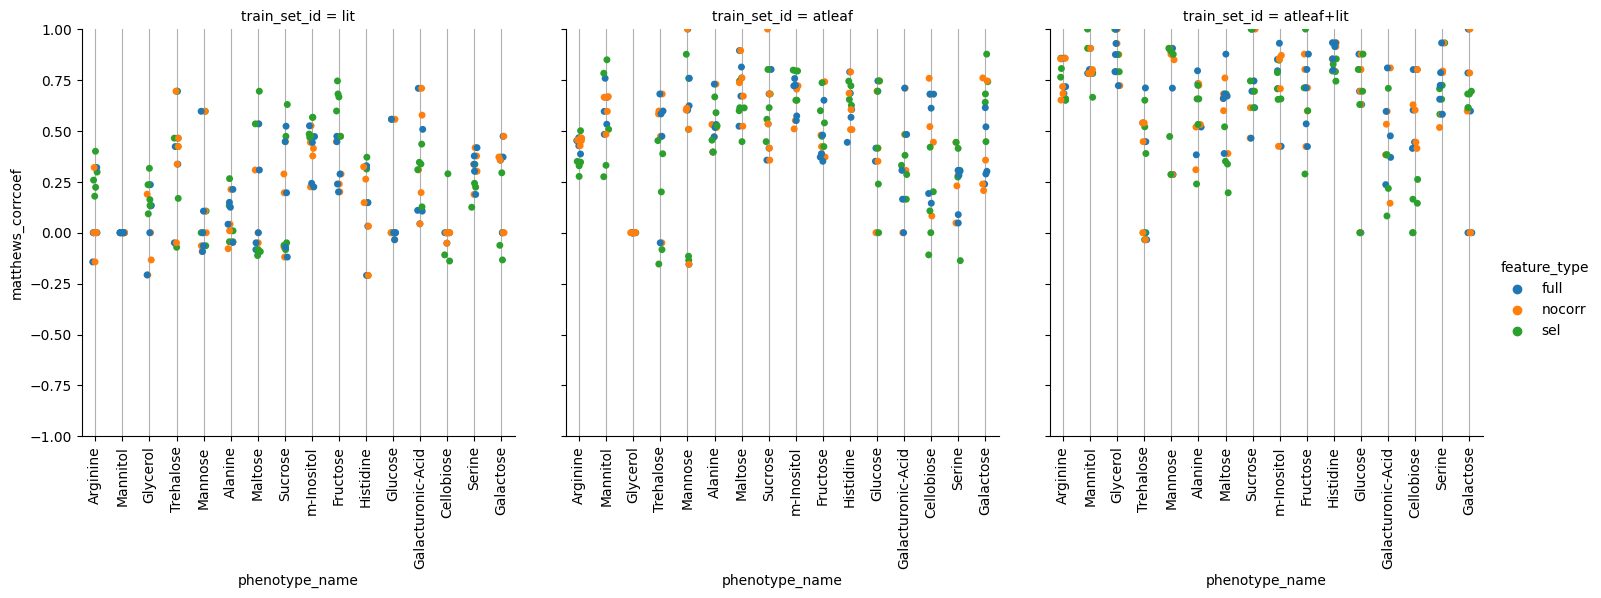

In [14]:
plot_data = results[(results.test_set_id.isin(["in_abb"])) & (results.train_set_id.isin(["atleaf", "lit", "atleaf+lit"]))]
hue_order = ["full", "nocorr", "sel"]
col_order = ["lit", "atleaf", "atleaf+lit"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="strip",
    col="train_set_id",
    hue_order=hue_order,
    col_order=col_order
    )
# g.fig.suptitle("Train(atleaf+lit+pmi), Test(uniform)")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


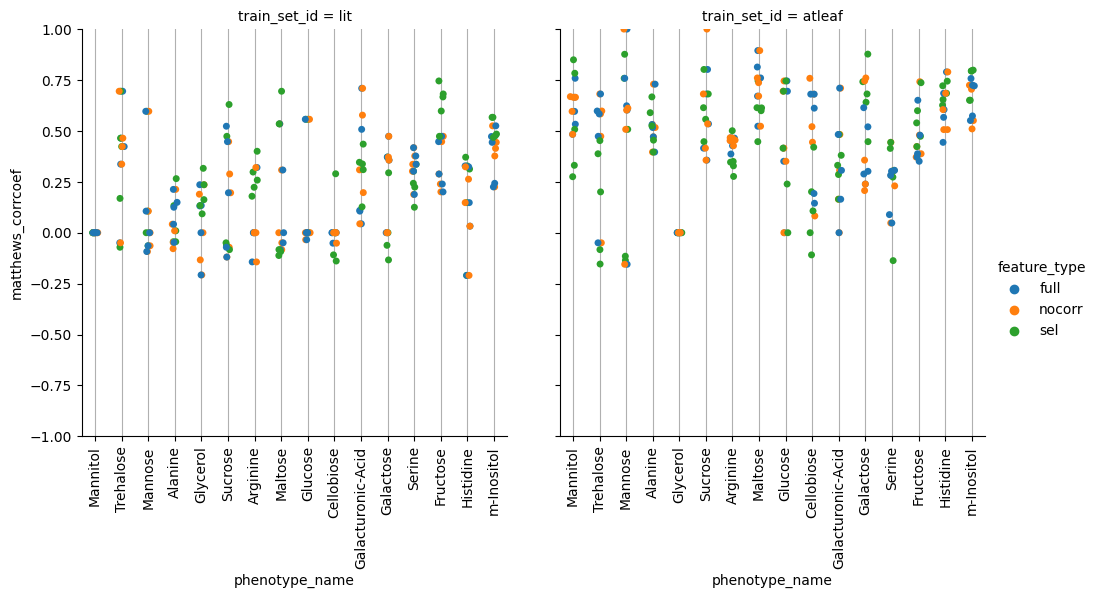

In [15]:
plot_data = results[(results.test_set_id.isin(["in_abb"])) & (results.train_set_id.isin(["atleaf", "lit"]))]
hue_order = ["full", "nocorr", "sel"]
col_order = ["lit", "atleaf"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="strip",
    col="train_set_id",
    hue_order=hue_order,
    col_order=col_order
    )
# g.fig.suptitle("Train(atleaf+lit+pmi), Test(uniform)")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)

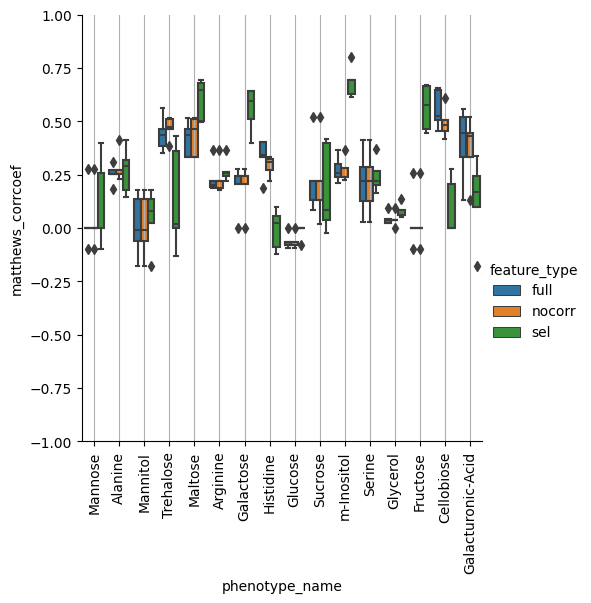

In [16]:
plot_data = results[(results.test_set_id.isin(["atleaf"])) & (results.train_set_id.isin(["lit"]))]
hue_order = ["full", "nocorr", "sel"]
g = sns.catplot(
    data=plot_data,
    x="phenotype_name",
    y="matthews_corrcoef",
    hue="feature_type",
    kind="box",
    hue_order=hue_order,
    )
# g.fig.suptitle("Train(atleaf+lit+pmi), Test(uniform)")
for i, ax in enumerate(g.axes.flat):
    ax.set_ylim(-1, 1)
    ax.grid(True, axis="x")
    for label in ax.get_xticklabels():
        label.set_rotation(90)